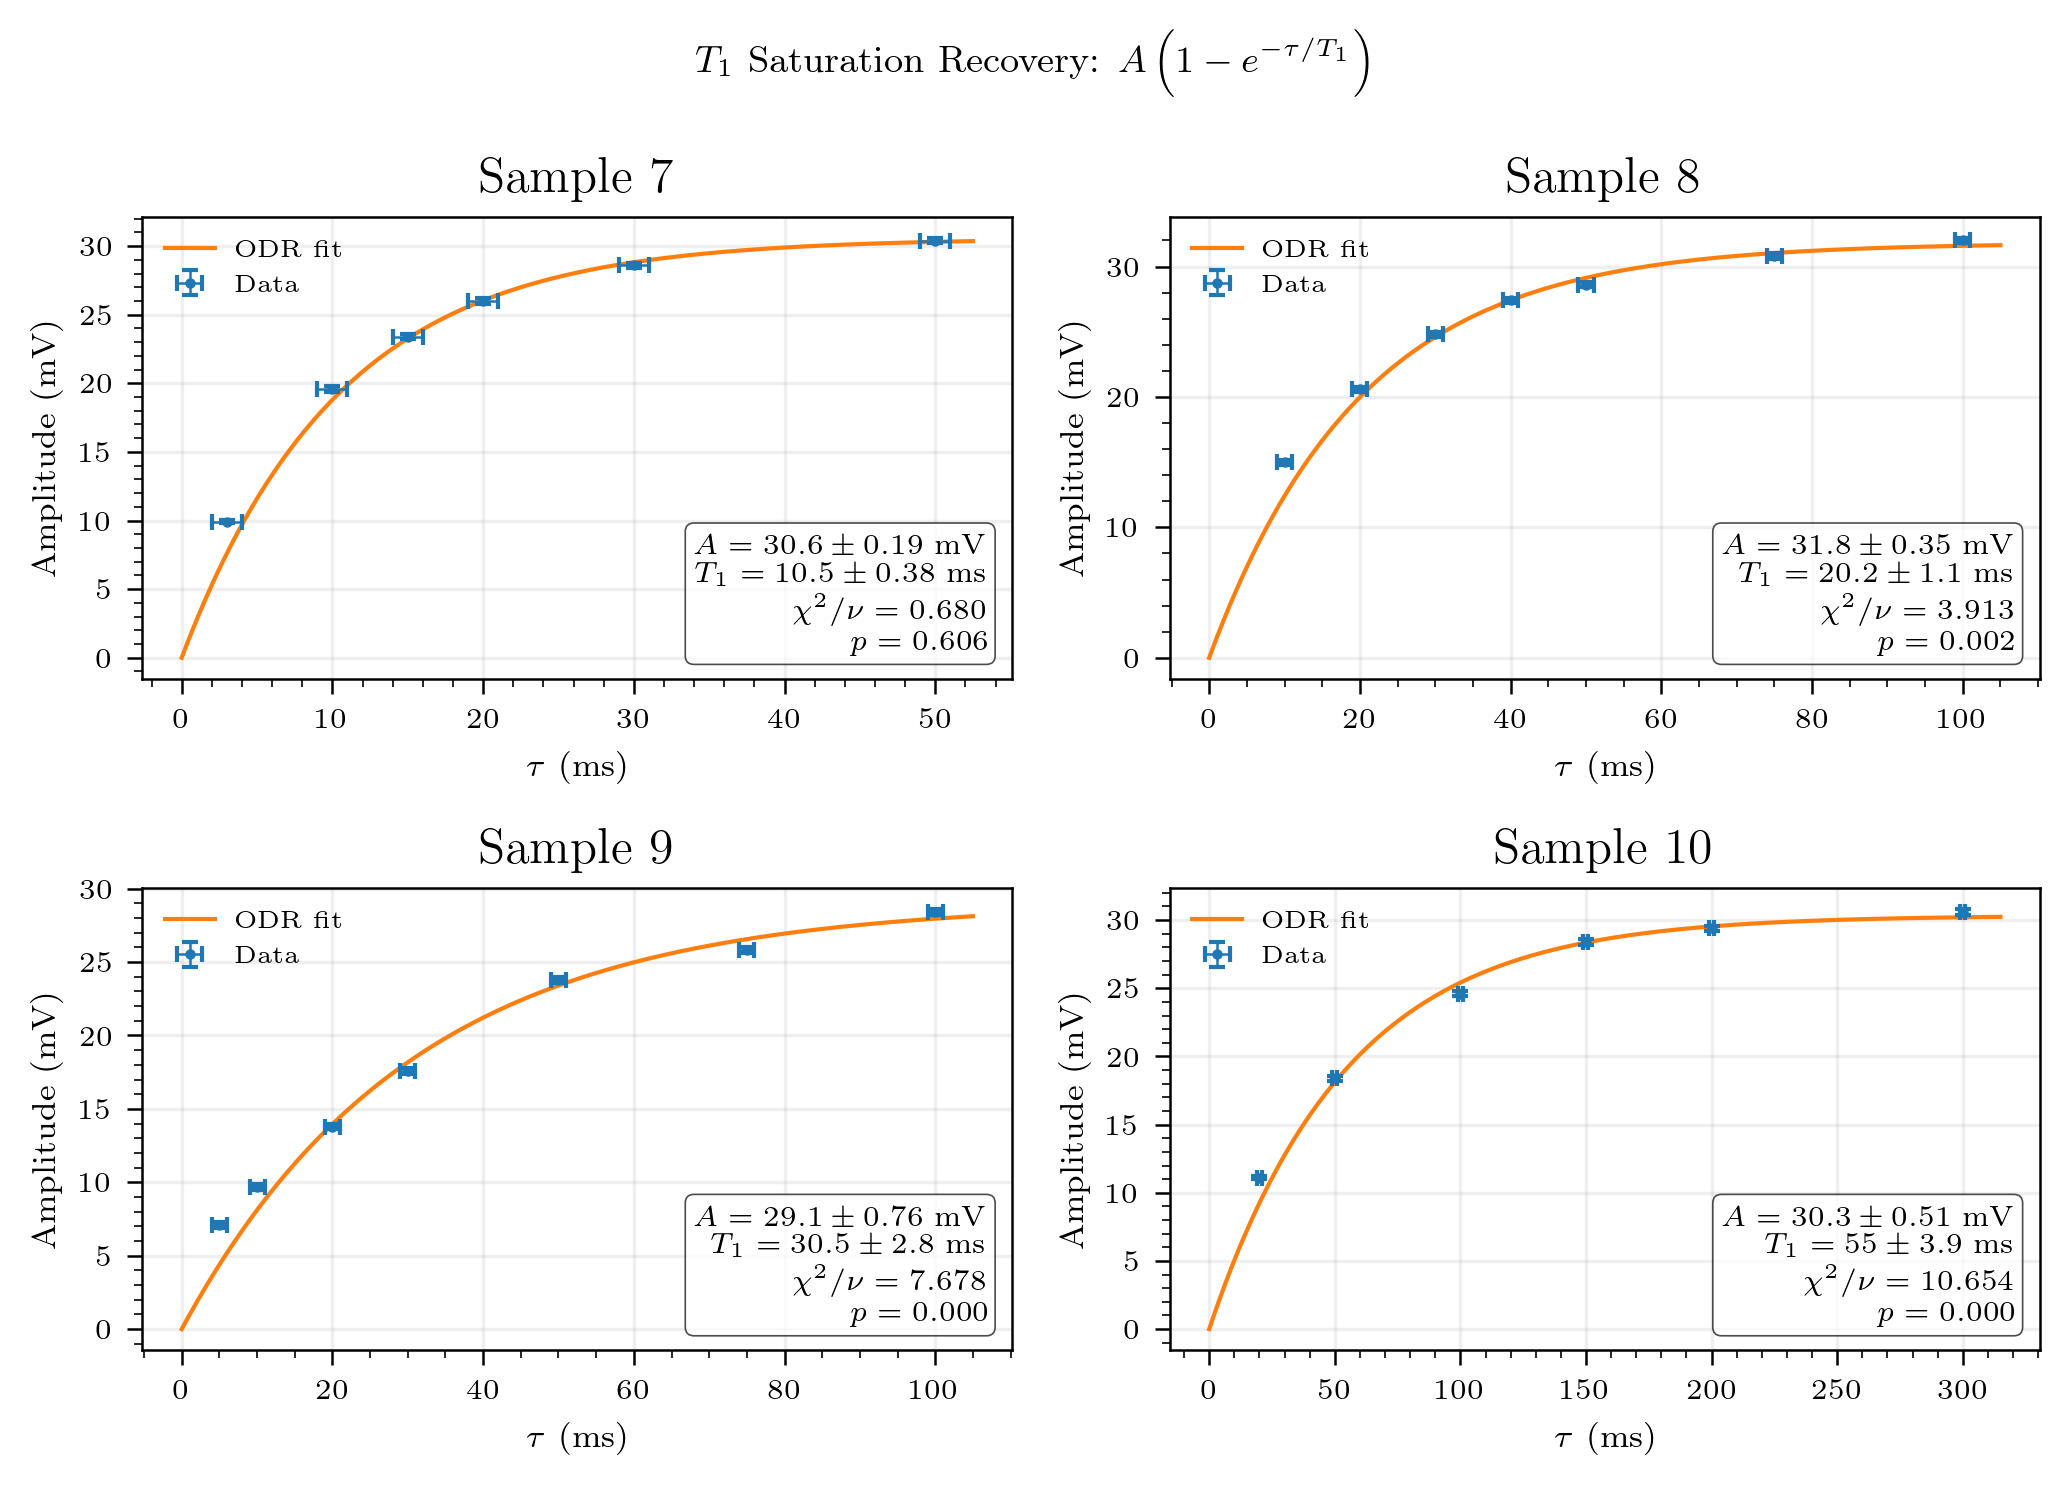

In [24]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from scipy.odr import ODR, Model, RealData

plt.style.use('./jlab.mplstyle')
os.makedirs('./graphs', exist_ok=True)

# Load raw FID amplitude data and concentration table
para       = pd.read_csv('ParamagneticData.csv')
conc_table = pd.read_csv('NMR Data - Concentrations.csv')

# Build integer-keyed lookup (skip non-numeric rows like "9 (2)")
conc_lookup = {
    int(row['Sample Number']): row['# ions/cc']
    for _, row in conc_table.iterrows()
    if str(row['Sample Number']).strip().lstrip('-').isdigit()
}

def saturation_model(beta, t):
    A, T = beta
    return A * (1.0 - np.exp(-t / T))

odr_model     = Model(saturation_model)
samples_order = sorted(para['Sample #'].unique())

# Output arrays passed to the Purcell plot cell
m_samples = np.array(samples_order)
m_ions    = np.array([conc_lookup[s] for s in samples_order])
m_tau     = np.zeros(len(samples_order))   # T1 in seconds
m_tau_err = np.zeros(len(samples_order))   # T1 uncertainty in seconds

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for i, (ax, sample) in enumerate(zip(axes, samples_order)):
    df    = para[para['Sample #'] == sample]
    t     = df['Tau (ms)'].values.astype(float)
    A_mV  = df['Amplitude (mV)'].values.astype(float)
    t_unc = df['Unc. Tau (ms)'].values.astype(float)
    A_unc = df['Unc. Amplitude (mV)'].values.astype(float)

    A0 = A_mV.max() * 1.2
    T0 = t[np.argmin(np.abs(A_mV - 0.63 * A_mV.max()))]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        odr_data = RealData(t, A_mV, sx=t_unc, sy=A_unc)
        odr_fit  = ODR(odr_data, odr_model, beta0=[A0, T0])
        out      = odr_fit.run()

    A_fit, T_fit = out.beta
    A_err, T_err = out.sd_beta

    m_tau[i]     = T_fit / 1000.0
    m_tau_err[i] = T_err / 1000.0

    chi2_val = out.sum_square
    dof      = len(t) - 2
    chi2_red = chi2_val / dof
    p_val    = chi2_dist.sf(chi2_val, dof)

    t_fine = np.linspace(0, t.max() * 1.05, 300)
    y_fine = saturation_model(out.beta, t_fine)

    ax.errorbar(t, A_mV, yerr=A_unc, xerr=t_unc,
                fmt='o', capsize=2, label='Data', zorder=3)
    ax.plot(t_fine, y_fine, lw=1, label='ODR fit', zorder=2)

    textstr = '\n'.join([
        rf'$A = {A_fit:.3g} \pm {A_err:.2g}$ mV',
        rf'$T_1 = {T_fit:.3g} \pm {T_err:.2g}$ ms',
        rf'$\chi^2/\nu = {chi2_red:.3f}$',
        rf'$p = {p_val:.3f}$',
    ])
    ax.text(0.97, 0.05, textstr, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_xlabel(r'$\tau$ (ms)')
    ax.set_ylabel(r'Amplitude (mV)')
    ax.set_title(rf'Sample {sample}')
    ax.legend()
    ax.grid(alpha=0.2)

fig.suptitle(r'$T_1$ Saturation Recovery: $A\left(1 - e^{-\tau/T_1}\right)$', fontsize=9)
fig.tight_layout()
fig.savefig('./graphs/saturation_recovery.pdf', bbox_inches='tight')
plt.show()


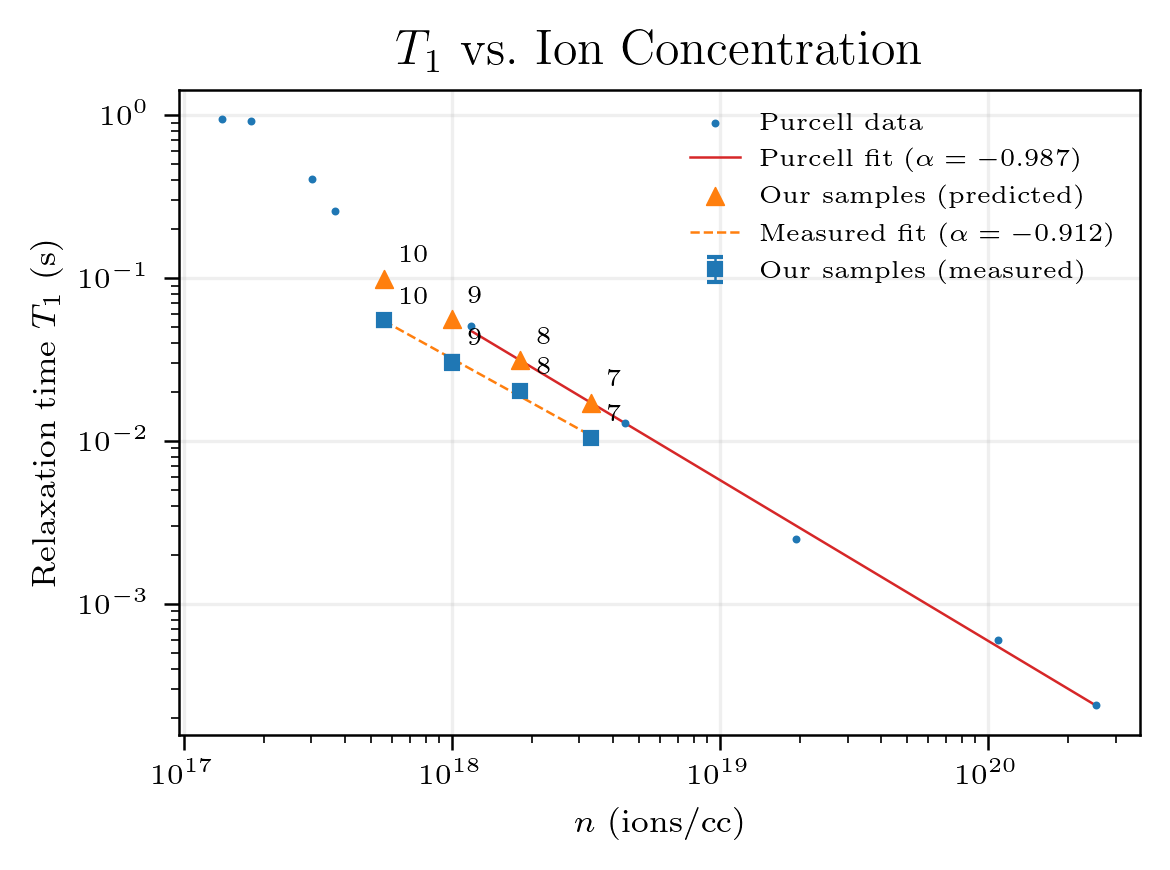

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
data = pd.read_csv('purcell_nmr.csv', header=None)

x = data[0].values.astype(float)
y = data[1].values.astype(float)

# Linear fit in log-log space, excluding first 4 points (smallest x)
idx = np.argsort(x)
x_sorted, y_sorted = x[idx], y[idx]
x_fit, y_fit = x_sorted[4:], y_sorted[4:]

coeffs = np.polyfit(np.log10(x_fit), np.log10(y_fit), 1)
slope, intercept = coeffs

x_line = np.logspace(np.log10(x_fit[0]), np.log10(x_fit[-1]), 300)
y_line = 10**intercept * x_line**slope

# Predicted T1 for studied samples only (m_ions from first cell)
predicted_T = 10**(slope * np.log10(m_ions) + intercept)

# Fit line through measured T1 values (extracted by ODR in the first cell)
m_coeffs = np.polyfit(np.log10(m_ions), np.log10(m_tau), 1)
m_slope, m_intercept = m_coeffs
m_x_line = np.logspace(np.log10(m_ions.min()), np.log10(m_ions.max()), 300)
m_y_line = 10**m_intercept * m_x_line**m_slope

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(x, y, label='Purcell data', zorder=3)
ax.plot(x_line, y_line, color='tab:red', label=rf'Purcell fit ($\alpha={slope:.3f}$)')
ax.scatter(m_ions, predicted_T, marker='^', s=18,
           label='Our samples (predicted)', zorder=4)
ax.errorbar(m_ions, m_tau, yerr=m_tau_err, fmt='s',
            capsize=2, markersize=3, label='Our samples (measured)', zorder=5)
ax.plot(m_x_line, m_y_line, linestyle='--', label=rf'Measured fit ($\alpha={m_slope:.3f}$)')

for sn, xi, ti in zip(m_samples, m_ions, predicted_T):
    ax.annotate(str(sn), (xi, ti),
                textcoords='offset points', xytext=(4, 4),
                fontsize=6, arrowprops=dict(arrowstyle='-', color='gray', lw=0.4))

for sn, xi, ti in zip(m_samples, m_ions, m_tau):
    ax.annotate(str(sn), (xi, ti),
                textcoords='offset points', xytext=(4, 4),
                fontsize=6, arrowprops=dict(arrowstyle='-', color='gray', lw=0.4))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$n$ (ions/cc)')
ax.set_ylabel(r'Relaxation time $T_1$ (s)')
ax.set_title(r'$T_1$ vs.\ Ion Concentration')
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('./graphs/purcell_comparison.pdf', bbox_inches='tight')
plt.show()


In [26]:
from IPython.display import display, Markdown

A_purcell  = 10**intercept
A_measured = 10**m_intercept

# Discrepancy in sigma for each sample
sigmas = (m_tau - predicted_T) / m_tau_err

rows = "\n".join(
    f"| {int(sn)} | ${xi:.3e}$ | ${tm*1000:.2f} \\pm {te*1000:.2f}$ | ${tp*1000:.2f}$ | ${sig:+.2f}$ |"
    for sn, xi, tm, te, tp, sig in zip(m_samples, m_ions, m_tau, m_tau_err, predicted_T, sigmas)
)

display(Markdown(f"""
## Relaxation time vs. ion concentration

Both fits take the power-law form $T_1 = A \\cdot n^{{\\,\\alpha}}$, where $n$ is in ions/cc and $T_1$ is in seconds.

|              | $A$ (s·(ions/cc)$^{{-\\alpha}}$) | $\\alpha$        |
|--------------|----------------------------------|-----------------|
| **Purcell**  | ${A_purcell:.3e}$                | ${slope:.3f}$   |
| **Our data** | ${A_measured:.3e}$               | ${m_slope:.3f}$ |

**Purcell:**  $T_1 = {A_purcell:.3e} \\cdot n^{{{slope:.3f}}}$

**Measured:** $T_1 = {A_measured:.3e} \\cdot n^{{{m_slope:.3f}}}$

### Per-sample comparison

| Sample | ions/cc | $T_1$ measured (ms) | $T_1$ Purcell (ms) | Discrepancy ($\\sigma$) |
|--------|---------|---------------------|--------------------|------------------------|
{rows}
"""))



## Relaxation time vs. ion concentration

Both fits take the power-law form $T_1 = A \cdot n^{\,\alpha}$, where $n$ is in ions/cc and $T_1$ is in seconds.

|              | $A$ (s·(ions/cc)$^{-\alpha}$) | $\alpha$        |
|--------------|----------------------------------|-----------------|
| **Purcell**  | $3.237e+16$                | $-0.987$   |
| **Our data** | $8.339e+14$               | $-0.912$ |

**Purcell:**  $T_1 = 3.237e+16 \cdot n^{-0.987}$

**Measured:** $T_1 = 8.339e+14 \cdot n^{-0.912}$

### Per-sample comparison

| Sample | ions/cc | $T_1$ measured (ms) | $T_1$ Purcell (ms) | Discrepancy ($\sigma$) |
|--------|---------|---------------------|--------------------|------------------------|
| 7 | $3.299e+18$ | $10.47 \pm 0.38$ | $17.22$ | $-17.71$ |
| 8 | $1.799e+18$ | $20.22 \pm 1.09$ | $31.32$ | $-10.21$ |
| 9 | $9.997e+17$ | $30.54 \pm 2.84$ | $55.95$ | $-8.94$ |
| 10 | $5.598e+17$ | $54.98 \pm 3.87$ | $99.15$ | $-11.43$ |


In [27]:
import pandas as pd
import numpy as np

samples = pd.read_csv('NMR Data - Concentrations.csv')
sample_nums = samples['Sample Number'].values
ions = samples['# ions/cc'].values.astype(float)

# Predict relaxation time using log-log linear fit: log10(y) = slope*log10(x) + intercept
predicted_T = 10**(slope * np.log10(ions) + intercept)

print(f"{'Sample':<10} {'Ions/cc':>20} {'Predicted T (ms)':>18}")
print("-" * 50)
for sn, xi, ti in zip(sample_nums, ions, predicted_T):
    print(f"{str(sn):<10} {xi:>20.4e} {ti*1000:>18.4e}")


Sample                  Ions/cc   Predicted T (ms)
--------------------------------------------------
1                    9.9968e+19         5.9453e-01
2                    5.5982e+19         1.0536e+00
3                    3.2989e+19         1.7754e+00
4                    1.7994e+19         3.2291e+00
5                    9.9968e+18         5.7674e+00
6                    5.5982e+18         1.0220e+01
7                    3.2989e+18         1.7223e+01
8                    1.7994e+18         3.1324e+01
9                    9.9968e+17         5.5949e+01
9 (2)                9.9968e+17         5.5949e+01
10                   5.5982e+17         9.9147e+01
11                   3.2989e+17         1.6708e+02
12                   1.7994e+17         3.0387e+02
13                   9.9968e+16         5.4275e+02
14                   5.5982e+16         9.6181e+02
15                   3.2989e+16         1.6208e+03
16                   1.7994e+16         2.9478e+03
17                   9.9968e+15